# Pricing autocalls with a stochastic-volatility model built from the stride up

### An idiot's guide, written for model validation

This notebook builds, calibrates and validates the **LogVar2FJ** model — two-factor log-variance with
co-jumps, priced through a *one-step-survival* Monte Carlo — and prices an autocall with it. It uses
only `numpy`, `scipy`, `pandas` and `matplotlib`, and it runs end to end in a few minutes on a laptop.

It is written to be read top to bottom. Every design decision is derived from a requirement stated
before it, every claim is checked by a number in the same notebook, and the places where the model is
*structurally* short of what a desk might want are stated rather than hidden. If you find a claim
without a number next to it, that is a bug in the document.

**The one-paragraph version.** An autocall pays a coupon the first time the stock is above a trigger
on an observation date, and otherwise sells you a put at maturity. Pricing it well needs (i) a
Monte Carlo estimator that does not turn the coupon's digital into noise, and (ii) a volatility model
whose smiles — today's *and* the smile conditional on having survived to a future date — look like the
market's. We solve (i) by conditioning on survival analytically, one observation at a time. That
forces the return over each observation interval to be **Gaussian given everything sampled before
it**, and we then ask what dynamics of variance are consistent with that. The answer is a model in
which everything non-Gaussian (vol level, vol-of-vol, jumps) is *sampled first*, and the return is a
Gaussian on top. Calibration to vanillas fixes today's smiles; a forward-smile target fixes the
conditional ones; the notebook shows what each part of the surface identifies and what it doesn't.

**Contents**
1. The product, and what drives its value
2. The estimator problem: digitals, noisy Greeks, and one-step survival (OSS) under Black–Scholes
3. Why we need a volatility model, and the *stride contract* it has to satisfy
4. Building the model slowly: variance state → cap → return → jumps → block Gaussian → stride
5. Calibration: conditional-Black vanillas, identification, the staged fit, sizing diagnostics, forward skew
6. Pricing the autocall: OSS vs brute force, Greeks, forward-skew sensitivity
7. The validation gates, with their numbers
8. What to remember


In [1]:
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt
from scipy.stats import norm, ks_2samp
from scipy.optimize import brentq, least_squares

Phi, Phinv = norm.cdf, norm.ppf
DAYS = 252                                   # business days per year: the model's clock
pd.set_option('display.precision', 4)
plt.rcParams['figure.figsize'] = (9, 4); plt.rcParams['axes.grid'] = True

def black(F, K, sd):
    """Undiscounted Black call price with a TOTAL standard deviation sd (not an annualised vol)."""
    sd = np.maximum(sd, 1e-12)
    d1 = (np.log(F / K) + 0.5 * sd ** 2) / sd
    return F * Phi(d1) - K * Phi(d1 - sd)

def implied_vol(call_price, F, K, T):
    """Annualised implied vol. Inverts on the out-of-the-money instrument (put for K<F, by parity)
    so that deep in-the-money calls, whose time value is tiny, do not spoil the inversion."""
    if K < F:
        target = call_price - (F - K)
        f = lambda v: (black(F, K, v * np.sqrt(T)) - (F - K)) - target
    else:
        target = call_price
        f = lambda v: black(F, K, v * np.sqrt(T)) - target
    if target <= 1e-12:
        return np.nan
    return brentq(f, 1e-4, 5.0)

def se(x):
    return x.std() / np.sqrt(len(x))


## 1. The product

A (simplified) **autocall** on a stock $S$, notional 1, with monthly observation dates $T_1 < \dots < T_n$:

* at the first observation $j$ with $S_{T_j} \ge \text{trigger}$ (here 100% of spot) the note **redeems** and pays a coupon $j \cdot c$ (we use $c = 2\%$ per period, accrued);
* if it never redeems, at maturity $T_n$ the holder is **short a put**: if $S_{T_n} < \text{barrier}$ (here 70%) the holder loses $1 - S_{T_n}/S_0$.

Everything else (rates, dividends, funding) is set to zero here so that the numbers are about the model, not the discounting. Rates and carry enter the model additively in one place, marked below.

Two things drive the value:

1. **The survival probabilities.** At each observation the note either fires or continues. The coupon strip is a sequence of digitals, and digitals are the hardest thing to Monte-Carlo well: their delta is a spike.
2. **The put, conditional on never having fired.** The put is only alive on paths that stayed *below* the trigger at every observation. Its value depends on the distribution of $S_{T_n}$ given that history — i.e. on the smile the model produces *conditional on the past*, which is a **forward smile**, not today's smile.

The plot shows one Black–Scholes path against the observation schedule. This particular path survives every observation (stays below 100%) and ends above the 70% barrier, so it pays nothing.


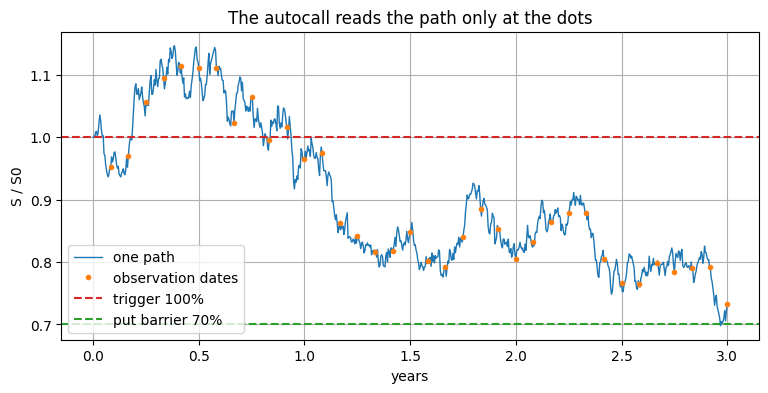

In [2]:
OBS_DAYS, N_OBS = 21, 36                     # monthly observations, three years
TRIGGER, BARRIER, COUPON = 1.00, 0.70, 0.02

rng = np.random.default_rng(0)
days = np.arange(OBS_DAYS * N_OBS + 1)
path = np.exp(np.cumsum(np.r_[0.0, 0.20 * np.sqrt(1 / DAYS) * rng.standard_normal(OBS_DAYS * N_OBS) - 0.5 * 0.04 / DAYS]))
obs = np.arange(1, N_OBS + 1) * OBS_DAYS

plt.plot(days / DAYS, path, lw=1, label='one path')
plt.plot(obs / DAYS, path[obs], 'o', ms=3, label='observation dates')
plt.axhline(TRIGGER, color='C3', ls='--', label='trigger 100%')
plt.axhline(BARRIER, color='C2', ls='--', label='put barrier 70%')
plt.xlabel('years'); plt.ylabel('S / S0'); plt.legend(loc='lower left'); plt.title('The autocall reads the path only at the dots'); plt.show()


## 2. The estimator problem, and one-step survival

### 2.1 Brute force

The obvious Monte Carlo simulates paths, checks the trigger at each date, and averages the payoff.
It is unbiased. It is also a poor estimator of the things a desk needs, because the coupon strip is a
sum of indicators $1\{S_{T_j} \ge K\}$: the value is fine, but the **delta** of an indicator is a Dirac
spike, so bump-and-revalue deltas are noise, and gammas are worse.

### 2.2 One-step survival (OSS)

Instead of *sampling* whether the note fires at $T_j$, we can **compute the probability** it fires,
conditional on the path so far, and split the path into a fired part (weight $1-p_j$, paid analytically)
and a surviving part (weight $p_j$) that continues. The surviving part must then be drawn from the
conditional law **given that it survived**, i.e. a truncated draw. Concretely, if the log-return over
the interval is $R \sim N(m, s^2)$ and the note survives when $R < x_{\text{cap}} := \log(K/S)$:

$$p = \Phi\!\left(\frac{x_{\text{cap}} - m}{s}\right), \qquad
R_{\text{surv}} = m + s\,\Phi^{-1}(u\,p),\quad u \sim U(0,1).$$

The estimator is unbiased for exactly the same quantity (this is the tower property: we integrate the
fire/survive coin analytically), every path carries a running survival weight $L_j = \prod_{i<j} p_i$,
and the digital has become a smooth function of the state. This is Glasserman & Staum's
*conditioning on one-step survival* (2001).

The put at maturity gets the same treatment: on the surviving mass we don't sample $S_{T_n}$ and apply
the payoff — we integrate the payoff against the surviving Gaussian in closed form (a lognormal
**partial moment**, i.e. Black's formula in disguise). No indicator is ever sampled.

**The requirement this creates**, and the whole reason the rest of the notebook looks the way it does:
*the return over an observation interval must be Gaussian, conditional on whatever we have already
sampled, with a mean and variance we can write down per path*. Under Black–Scholes that is trivially
true. Under a stochastic-volatility model it is a design constraint, and section 3 turns it into one.

Below: Black–Scholes at 20% vol, the two estimators side by side.


In [3]:
def gbm_block_stats(sigma, n_paths, n_blocks, dt_block):
    """Under Black-Scholes every block return is N(-sigma^2 dt/2, sigma^2 dt): same for every path."""
    m = np.full((n_paths, n_blocks), -0.5 * sigma ** 2 * dt_block)
    s2 = np.full((n_paths, n_blocks), sigma ** 2 * dt_block)
    return m, s2

def autocall_oss_from_stats(M, S2, u_block, S0, trigger, barrier, coupon):
    """OSS pricer on per-path block Gaussians (M, S2). Works for ANY model that supplies them."""
    n, nb = M.shape
    logS = np.full(n, np.log(S0)); Lw = np.ones(n); pv = np.zeros(n)
    for j in range(nb):
        m, sd = M[:, j], np.sqrt(S2[:, j])
        x_cap = np.log(trigger) - logS                      # survive below the trigger
        p = Phi((x_cap - m) / sd)
        pv += Lw * (1.0 - p) * (j + 1) * coupon             # fired mass pays the coupon
        if j == nb - 1:                                     # put leg on the surviving mass, integrated:
            zB = (np.log(barrier) - logS - m) / sd          # E[(S_T - 1) 1{S_T < B}] = lognormal partial moments
            put = np.exp(logS + m + 0.5 * sd ** 2) * Phi(zB - sd) - Phi(zB)
            pv += Lw * put
        Lw = Lw * p
        u = np.clip(u_block[:, j] * p, 1e-16, 1 - 1e-16)
        logS = logS + m + sd * Phinv(u)                     # truncated draw: the survivor's return
    return pv

def autocall_brute_from_returns(R, S0, trigger, barrier, coupon):
    """Brute force on sampled block returns R [paths, blocks]."""
    n, nb = R.shape
    logS = np.log(S0) + np.cumsum(R, axis=1)
    alive = np.ones(n, bool); pv = np.zeros(n)
    for j in range(nb):
        fired = alive & (logS[:, j] >= np.log(trigger))
        pv += fired * (j + 1) * coupon
        alive &= ~fired
    ST = np.exp(logS[:, -1])
    pv += alive * np.where(ST < barrier, ST - 1.0, 0.0)
    return pv

SIGMA_BS, N = 0.20, 2 ** 16
dt_block = OBS_DAYS / DAYS
rng = np.random.default_rng(1)
u_block = rng.uniform(size=(N, N_OBS)); eps = rng.standard_normal((N, N_OBS))

M, S2 = gbm_block_stats(SIGMA_BS, N, N_OBS, dt_block)
pv_oss = autocall_oss_from_stats(M, S2, u_block, 1.0, TRIGGER, BARRIER, COUPON)
pv_brute = autocall_brute_from_returns(M + np.sqrt(S2) * eps, 1.0, TRIGGER, BARRIER, COUPON)
pd.DataFrame({'value': [pv_brute.mean(), pv_oss.mean()], 'std error': [se(pv_brute), se(pv_oss)]},
             index=['brute force', 'one-step survival']).round(5)


,value,std error
brute force,0.0389,0.0007
one-step survival,0.0377,0.0003


Same value within a standard error, as it must be; the standard error is smaller under OSS. The
real difference is in the Greeks. Below, the price as a function of spot on a ladder of bumps, with
common random numbers, for both estimators. The brute-force ladder is a staircase — its finite-difference
delta depends on which paths happened to cross a trigger — while the OSS ladder is smooth.


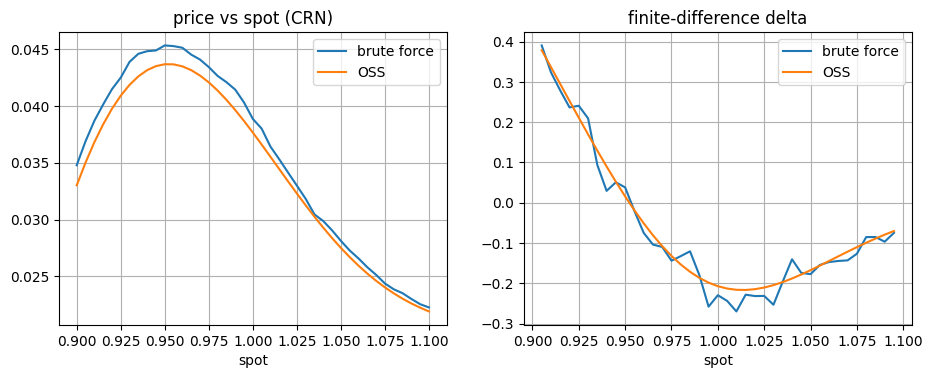

In [4]:
spots = np.linspace(0.90, 1.10, 41)
oss_ladder = [autocall_oss_from_stats(M, S2, u_block, s, TRIGGER, BARRIER, COUPON).mean() for s in spots]
brute_ladder = [autocall_brute_from_returns(M + np.sqrt(S2) * eps, s, TRIGGER, BARRIER, COUPON).mean() for s in spots]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(spots, brute_ladder, label='brute force'); ax[0].plot(spots, oss_ladder, label='OSS'); ax[0].set_title('price vs spot (CRN)'); ax[0].legend(); ax[0].set_xlabel('spot')
ax[1].plot(spots[1:-1], np.gradient(brute_ladder, spots)[1:-1], label='brute force'); ax[1].plot(spots[1:-1], np.gradient(oss_ladder, spots)[1:-1], label='OSS')
ax[1].set_title('finite-difference delta'); ax[1].legend(); ax[1].set_xlabel('spot'); plt.show()


## 3. Why a volatility model, and the stride contract

### 3.1 The market is not Black–Scholes

Index options trade on a **smile**: out-of-the-money puts are priced on a higher implied vol than
calls (skew), both wings sit above the middle (convexity), and the shape changes with maturity
(the term structure). The autocall's put barrier at 70% lives in the left wing; its coupon strip lives
around the money; a model that gets one of those right and the other wrong is worse than useless,
because it will look calibrated.

Below is the *stylised* market surface we calibrate to in this notebook. It is generated by an SVI
parametrisation with index-like values (steep one-month skew that decays with maturity, a put wing
above 25%, a flat-ish call wing), so that the exercise is honest without needing a data feed. Replace
it with real quotes and nothing else in the notebook changes.


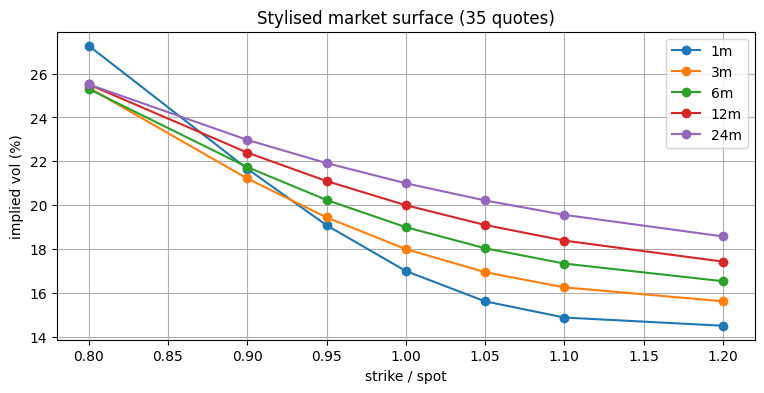

,80%,90%,95%,100%,105%,110%,120%
1m,27.3,21.7,19.1,17.0,15.6,14.9,14.5
3m,25.4,21.2,19.4,18.0,16.9,16.3,15.6
6m,25.3,21.7,20.2,19.0,18.0,17.3,16.5
12m,25.5,22.4,21.1,20.0,19.1,18.4,17.4
24m,25.5,23.0,21.9,21.0,20.2,19.6,18.6


In [5]:
def svi_surface(strikes, T, atm, vol_skew, rho=-0.8, sig=None):
    """Per-maturity SVI (Gatheral) with m=0: w(k) = a + b(rho k + sqrt(k^2 + sig^2)), parametrised by the
    ATM vol, the ATM vol skew per unit log-strike, the wing asymmetry rho and a smoothing width sig."""
    k = np.log(strikes); out = []
    for i, (t, a_vol, s_v) in enumerate(zip(T, atm, vol_skew)):
        sg = (0.25 * np.sqrt(t) + 0.06) if sig is None else sig[i]
        b = 2.0 * s_v * a_vol * t / rho              # dw/dk = b*rho at k = 0  ->  vol skew s_v
        a = a_vol ** 2 * t - b * sg
        w = a + b * (rho * k + np.sqrt(k ** 2 + sg ** 2))
        out.append(np.sqrt(np.maximum(w, 1e-8) / t))
    return np.array(out)

MATS = [1, 3, 6, 12, 24]                                     # maturities in months (= blocks of 21 days)
T_MATS = np.array(MATS) * OBS_DAYS / DAYS
STRIKES = np.array([0.80, 0.90, 0.95, 1.00, 1.05, 1.10, 1.20])
ATM = np.array([0.17, 0.18, 0.19, 0.20, 0.21])
VOL_SKEW = np.array([-0.35, -0.25, -0.22, -0.20, -0.17])     # d(iv)/d(log K) at the money
MARKET = svi_surface(STRIKES, T_MATS, ATM, VOL_SKEW)

for i, m in enumerate(MATS):
    plt.plot(STRIKES, 100 * MARKET[i], 'o-', label=f'{m}m')
plt.xlabel('strike / spot'); plt.ylabel('implied vol (%)'); plt.legend(); plt.title('Stylised market surface (35 quotes)'); plt.show()
pd.DataFrame(100 * MARKET, index=[f'{m}m' for m in MATS], columns=[f'{int(100*k)}%' for k in STRIKES]).round(1)


### 3.2 The stride contract

Call a **stride** the move from one observation date to the next. From section 2, an OSS pricer needs,
per path and per stride:

| | requirement | why |
|---|---|---|
| (a) | the survival probability in closed form | the coupon's digital, integrated |
| (b) | the survival-truncated draw as a closed-form quantile | continuing paths |
| (c) | partial moments $E[S'^a 1\{S' < B\}]$ in closed form | the put leg, integrated |
| (d) | the state after the stride carried **exactly** | otherwise the next stride is priced off the wrong state |
| (e) | the martingale condition exact | otherwise the forward is wrong by construction |
| (f) | one primitive for any interval length | products and risk grids don't share a calendar |
| (g) | everything smooth in state and parameters | Greeks, and calibration by gradient |

(a)+(b)+(c) with a *closed-form inverse* leave exactly one family: the return over a stride must be
**Gaussian, conditional on everything drawn before it**. Every non-Gaussian feature the smile needs —
vol level, vol-of-vol, skew, jumps — must therefore be **sampled first and conditioned on, never
integrated inside the stride**. The smile is a property of the *population* of paths; no single path
has one.

(d) then says the variance state must be drawn *before* the return and must not depend on the return's
own shock $\varepsilon$: the truncation acts on $\varepsilon$ only, the state never sees it, and the carry is
exact. This is the point where GARCH-type models (Heston–Nandi, CJOW) are ruled out: there the variance is
built from the return shock itself, so a truncated return contaminates the state, and the state after a
stride has to be *approximated*. It is also why the model below has **two shocks** — one the variance
sees, one it doesn't — and why that has a cost we will measure (section 5.3).

(f) says a stride of one month must have the same law as four strides of one week. The model is
defined as a Markov chain on a fine internal step $\delta$ (we use 7 business days here for speed;
one day in production), and a stride is a *block* of internal steps. The internal step is a numerical
setting; section 7 checks convergence in it.

Everything in section 4 is the shortest path through those seven requirements.


## 4. Building the model, slowly

### 4.1 The variance state

Two Gaussian AR(1) processes (discretised Ornstein–Uhlenbeck) in **log** variance — a slow factor
$\ell$ that reverts to a deterministic curve $L(t)$ and a fast factor $s$ that reverts to zero — and
the instantaneous variance $h = e^{\ell + s}$:

$$\ell_{k+1} = L(t_{k+1}) + \phi_\ell(\ell_k - L(t_k)) + w_\ell\,\eta^\ell_{k},\qquad
s_{k+1} = \phi_s s_k + w_s\,\eta^s_{k},\qquad
\phi_i = e^{-\kappa_i\delta},\; w_i = \sigma_i\sqrt{\tfrac{1-\phi_i^2}{2\kappa_i}}.$$

Why this and not something else:

* **Positive by construction.** $h = e^{\ell+s} > 0$. There is no floor anywhere in this model, and
  section 7 checks that claim by grepping for one. Floors are how variance models usually acquire bugs.
* **Exact transitions for any $\delta$.** The OU step above is the *exact* law of the continuous
  process over $\delta$, so requirement (f) holds for the state.
* **Mean reversion at two speeds**, and a **long-run level** that is itself stochastic: the slow factor
  is what puts a realistic distribution of *future* vol levels into anything priced years out.
* **Vol-of-vol proportional to vol**, because the noise is in the log. That is what implied-vol
  indices actually do.
* The curve $L(t)$ carries the **term structure**: it is what the ATM vols will calibrate.

The parameters below are sized to the **risk-neutral** measure, not to realised vol: the instantaneous
leverage covariance $\rho_s\sigma_s$ is what index skew is made of, and the market's own number for it
comes from VIX-vs-SPX daily co-movements (≈ −1.9), not from realised-vol regressions (≈ −0.9). Sizing
this to the wrong measure produced exactly half the market's skew in an earlier version of this
model — which is the first thing to check when a model "can't fit".


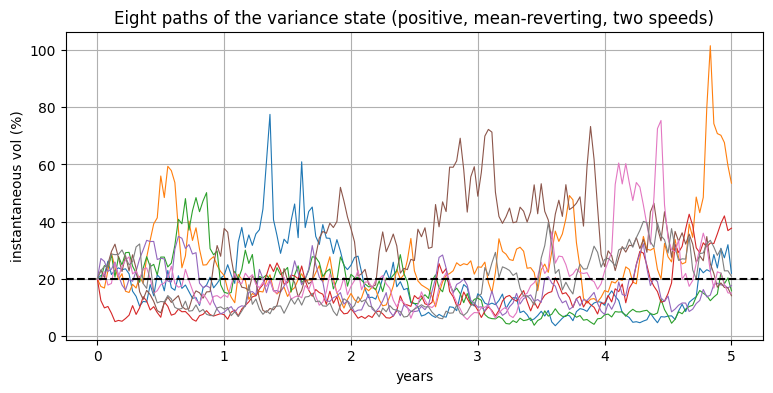

stationary sd of log-vol at these parameters: 0.61   (VIX options imply 0.5-0.8 at one year)
leverage products  rho_s*sigma_s = -1.80,  rho_l*sigma_l = -0.40   (index skew needs the fast one near -1.9)


In [6]:
P = dict(kappa_l=0.5, sigma_l=1.0, rho_l=-0.4,        # slow factor: reversion (1/yr), vol-of-log-variance, leverage
         kappa_s=6.0, sigma_s=2.4, rho_s=-0.75,       # fast factor
         lam=0.21, mu_J=-0.15, sigma_J=0.08, nu=0.3,  # jumps: intensity (1/yr), mean & sd of log-jump, variance co-jump
         cap_a=np.log(100.0), cap_beta=0.25)          # the cap (4.2)

N_SUB = 3                                             # internal steps per 21-day block (7 business days each)
dt = OBS_DAYS / DAYS / N_SUB

def ou_coeffs(P, dt):
    phi_l, phi_s = np.exp(-P['kappa_l'] * dt), np.exp(-P['kappa_s'] * dt)
    w_l = P['sigma_l'] * np.sqrt((1 - phi_l ** 2) / (2 * P['kappa_l']))
    w_s = P['sigma_s'] * np.sqrt((1 - phi_s ** 2) / (2 * P['kappa_s']))
    return phi_l, phi_s, w_l, w_s

def stationary_logvol_sd(P):
    """Stationary standard deviation of log-VOL (half of log-variance): the model's own vol-of-vol gauge."""
    return 0.5 * np.sqrt(P['sigma_s'] ** 2 / (2 * P['kappa_s']) + P['sigma_l'] ** 2 / (2 * P['kappa_l']))

# simulate the state alone for five years, flat curve at 20% vol
rng = np.random.default_rng(2); n_steps = 5 * DAYS // 7; L_flat = np.log(0.04)
phi_l, phi_s, w_l, w_s = ou_coeffs(P, dt)
ell = np.full(8, L_flat); s = np.zeros(8); vols = [np.exp(0.5 * (ell + s))]
for k in range(n_steps):
    s = phi_s * s + w_s * rng.standard_normal(8)
    ell = L_flat + phi_l * (ell - L_flat) + w_l * rng.standard_normal(8)
    vols.append(np.exp(0.5 * (ell + s)))
plt.plot(np.arange(n_steps + 1) * dt, 100 * np.array(vols), lw=0.8); plt.axhline(20, color='k', ls='--')
plt.ylabel('instantaneous vol (%)'); plt.xlabel('years'); plt.title('Eight paths of the variance state (positive, mean-reverting, two speeds)'); plt.show()
print(f"stationary sd of log-vol at these parameters: {stationary_logvol_sd(P):.2f}   (VIX options imply 0.5-0.8 at one year)")
print(f"leverage products  rho_s*sigma_s = {P['rho_s']*P['sigma_s']:.2f},  rho_l*sigma_l = {P['rho_l']*P['sigma_l']:.2f}   (index skew needs the fast one near -1.9)")


### 4.2 The cap: structural, and not a floor

A lognormal variance has a well-known wart: $E[S^p] = \infty$ for every $p > 1$, at every horizon,
because $E[S^2] = E[e^{\int h}]$ and the exponential of a lognormal has no moments. Bounded payoffs
(coupons, the put) don't care. Power payoffs and convexity adjustments do, and so does floating-point
arithmetic on the one path in ten million that reaches 2000% vol.

So the variance the return *reads* is $e^{\text{cap}(\ell+s)}$ with a smooth cap
$\text{cap}(x) = a - \beta\,\text{softplus}((a-x)/\beta)$, at $a = \log(100)$ — 1000% vol — and
$\beta = 0.25$. The state itself is never capped. The bias is closed form,
$x - \text{cap}(x) = \beta\log(1 + e^{-(a-x)/\beta})$, and the table shows it is below $10^{-14}$ at 20% vol,
$4\times10^{-6}$ in log-variance at 250% vol and only becomes visible ($10^{-2}$) at 700%. Its purpose is finite moments and no overflow —
nothing else. A calibration that pushes paths within five widths of the cap is reported as a
calibration failure, not absorbed (section 5.3 measures the headroom).


In [7]:
def cap(x, a, beta):
    return a - beta * np.logaddexp(0.0, (a - x) / beta)

vol_pct = np.array([20, 60, 150, 250, 400, 700])
x = np.log((vol_pct / 100) ** 2)
pd.DataFrame({'vol (%)': vol_pct, 'log-variance x': x.round(2), 'bias x - cap(x)': (x - cap(x, P['cap_a'], P['cap_beta']))})


,vol (%),log-variance x,bias x - cap(x)
0,20,-3.22,6.6613e-15
1,60,-1.02,4.1990e-11
2,150,0.81,6.4072e-08
3,250,1.83,3.8147e-06
4,400,2.77,1.6379e-04
5,700,3.89,1.4012e-02


### 4.3 The return given the state, and the martingale

One internal step. With the base variance $V_k = \delta\, e^{\text{cap}(\ell_k + s_k)}$ read from the
state **at the start of the step** (so it is *predictable*, in the sense of requirement (d)):

$$R_k = b_k\delta - \tfrac12 V_k + \rho_\ell\sqrt{V_k}\,\eta^\ell_k + \rho_s\sqrt{V_k}\,\eta^s_k
+ \sqrt{c\,V_k}\;\varepsilon_k,\qquad c = 1 - \rho_s^2 - \rho_\ell^2 .$$

Read it as three shocks. Two of them are the shocks that move the variance state ($\eta^\ell, \eta^s$),
entering the return with the leverage weights $\rho$ — that is the correlation between returns and
vol, and it is the *only* place skew comes from until we add jumps. The third, $\varepsilon$, is the
return's own shock, the one the variance never sees, carrying a share $c$ of the diffusive variance.
$b_k$ is the carry (rates minus dividends); it enters here and nowhere else.

**Martingale, exactly.** Given $(\eta^\ell,\eta^s)$ the return is Gaussian, so
$E[e^{R_k}\mid\eta] = e^{b_k\delta}\cdot e^{\rho_\ell\sqrt{V}\eta^\ell - \frac12\rho_\ell^2 V}\cdot e^{\rho_s\sqrt{V}\eta^s - \frac12\rho_s^2 V}$;
each factor has expectation one over its own shock, and $V_k$ is independent of the step's shocks because
it was read before them. So $E[S_{k+1}] = S_k e^{b_k\delta}$ with **no correction term anywhere** — the
compensators $-\tfrac12 V_k$ split as $-\tfrac12(\rho_\ell^2 + \rho_s^2 + c)V_k$ are the whole story.
This is the Romano–Touzi / Willard "mixing" structure: condition on the volatility path and the
option is Black's formula. We check it numerically in 4.5.

**The dial $c$.** $c=1$ is Black–Scholes (maximal OSS conditioning, no leverage skew); $c \to 0$ is
GARCH (one shock; Heston–Nandi's return/variance correlation is $-2\gamma\sqrt h/\sqrt{2+4\gamma^2 h}\approx -0.99$).
Skew per unit of smile convexity scales with the correlation $\sqrt{1-c}$, and OSS efficiency scales
with $c^{3/2}$ (the conditioning standard deviation is $\sqrt c$ of the interval's). We floor $c$ at
0.12 in the calibrator and report where it lands.


### 4.4 Jumps

Leverage alone cannot make a one-month smile as steep as an index market's: a diffusion's skew at
short maturities is bounded. So the return carries a compound-Poisson component, and the same event
kicks the fast variance up (a *co-jump*): a crash and a vol spike are one event, which is how the
world looks.

Per internal step, $N_k \sim \text{Poisson}(\lambda\delta)$ jumps, each with a Gaussian log-size
$N(\mu_J, \sigma_J^2)$. Two points make this cheap and exact:

* **Given the count, $N$ Gaussian jump sizes sum to one Gaussian** $N(N_k\mu_J, N_k\sigma_J^2)$, so the
  step return stays Gaussian per path and the *same* normal $\varepsilon_k$ carries both diffusion and jumps:
  $\text{var}_k = c\,V_k + N_k\sigma_J^2$, mean shifted by $N_k\mu_J$. Nothing is drawn per jump.
* The martingale needs the compensator $\text{comp}_k = \lambda\delta\,(e^{\mu_J + \sigma_J^2/2} - 1)$
  subtracted from the mean; then $E[e^{N\mu_J + \frac12 N\sigma_J^2 - \text{comp}}] = 1$ exactly.

The count is drawn by inverse CDF from one uniform (truncated at 3 per step, error $\sim 10^{-11}$).
It is an integer, so it has no derivative: **the jump intensity $\lambda$ is a structural parameter**,
fixed across days and chosen by a rule (5.2), so that every pathwise derivative the model reports is
exact. Jump size, dispersion, the co-jump size $\nu$, both leverages, both vol-of-vols and the curve all
stay differentiable.

After the step, the fast factor is raised by $\nu N_k$ — the co-jump — before the next step reads it.


In [8]:
def poisson_counts(u, rate):
    """Inverse-CDF Poisson counts from uniforms, truncated at 3 per step (rate ~ 0.006 here)."""
    p0 = np.exp(-rate); p1 = p0 * rate; p2 = p1 * rate / 2.0
    return (u > p0).astype(int) + (u > p0 + p1) + (u > p0 + p1 + p2)

u = np.random.default_rng(3).uniform(size=2_000_000)
counts = poisson_counts(u, P['lam'] * dt)
rate = P['lam'] * dt
pd.DataFrame({'empirical': np.bincount(counts, minlength=4) / len(u),
              'Poisson': [np.exp(-rate) * rate ** n / [1, 1, 2, 6][n] for n in range(4)]},
             index=['0 jumps', '1', '2', '3']).map(lambda v: f'{v:.2e}')


,empirical,Poisson
0 jumps,9.94e-01,9.94e-01
1,5.71e-03,5.80e-03
2,1.70e-05,1.69e-05
3,0.00e+00,3.29e-08


### 4.5 The walk, and the block Gaussian

Now the whole thing. One function walks the variance state over the internal grid and, for every
**block** (the steps between two observation dates), accumulates the two numbers the stride needs:

$$M_j = \sum_{k\in B_j} m_k,\qquad \Sigma_j^2 = \sum_{k\in B_j}\text{var}_k .$$

Because the internal-step returns are independent Gaussians *given the shocks and counts*, their sum
over a block is $N(M_j, \Sigma_j^2)$ — **exactly**, not approximately. So returns are never drawn on
unmonitored steps; the state is walked, and one Gaussian is drawn per observation date, conditioned on
the whole interval. This is the Rao–Blackwellised version of the fine-grid model, and it is what gives
the OSS conditioning its full-interval scale.

The function also (optionally) draws a brute-force return per block with a fresh $\varepsilon$, sharing
the same variance path, so that the two estimators can be compared with common random numbers in the
variance dimension.


In [9]:
class Grid:
    """Business-day clock cut into blocks of `block_days`, each with `n_sub` internal steps."""
    def __init__(self, block_days=OBS_DAYS, n_blocks=N_OBS, n_sub=N_SUB):
        self.block_days, self.n_blocks, self.n_sub = block_days, n_blocks, n_sub
        self.dt = block_days / DAYS / n_sub
        self.n_steps = n_blocks * n_sub
        self.t = np.arange(self.n_steps + 1) * self.dt
        self.block_end_t = np.arange(1, n_blocks + 1) * block_days / DAYS

def draws(grid, n_paths, rng, antithetic=True):
    """All randomness for one walk: two normals + one uniform per internal step (state and counts),
    one uniform per block (OSS truncated draw), one normal per step (brute force only)."""
    h = n_paths // 2 if antithetic else n_paths
    eta_l = rng.standard_normal((h, grid.n_steps)); eta_s = rng.standard_normal((h, grid.n_steps))
    uN = rng.uniform(size=(h, grid.n_steps))
    if antithetic:
        eta_l = np.concatenate([eta_l, -eta_l]); eta_s = np.concatenate([eta_s, -eta_s]); uN = np.concatenate([uN, 1 - uN])
    n = eta_l.shape[0]
    return dict(eta_l=eta_l, eta_s=eta_s, uN=uN, u_block=rng.uniform(size=(n, grid.n_blocks)),
                eps=rng.standard_normal((n, grid.n_steps)))

def bucket_on_grid(grid, bucket_t, values):
    """A piecewise-constant function of calendar time on the internal grid (used in 5.4)."""
    idx = np.searchsorted(bucket_t, grid.t[:-1], side='right') - 1
    return np.asarray(values, float)[np.clip(idx, 0, len(values) - 1)]

def walk(grid, P, L, d, rho_s_t=None, mu_J_t=None, carry_block=0.0, brute=False):
    """Walk the variance state; return per-block Gaussian statistics M, S2 [paths, blocks]
    (and brute-force block returns Rb if asked). L is the curve on the grid (n_steps + 1 values)."""
    n, ns = d['eta_l'].shape
    rho_s_t = np.full(ns, P['rho_s']) if rho_s_t is None else rho_s_t
    mu_J_t = np.full(ns, P['mu_J']) if mu_J_t is None else mu_J_t
    phi_l, phi_s, w_l, w_s = ou_coeffs(P, grid.dt)
    ell = np.full(n, L[0]); s = np.zeros(n)
    M = np.zeros((n, grid.n_blocks)); S2 = np.zeros((n, grid.n_blocks)); Rb = np.zeros((n, grid.n_blocks)) if brute else None
    for k in range(ns):
        b = k // grid.n_sub
        V = grid.dt * np.exp(cap(ell + s, P['cap_a'], P['cap_beta']))          # PREDICTABLE: read before the shocks
        rs, mJ = rho_s_t[k], mu_J_t[k]
        c = 1.0 - rs ** 2 - P['rho_l'] ** 2
        N = poisson_counts(d['uN'][:, k], P['lam'] * grid.dt)
        comp = P['lam'] * grid.dt * (np.exp(mJ + 0.5 * P['sigma_J'] ** 2) - 1.0)
        m = -0.5 * V + P['rho_l'] * np.sqrt(V) * d['eta_l'][:, k] + rs * np.sqrt(V) * d['eta_s'][:, k] + N * mJ - comp
        var = c * V + N * P['sigma_J'] ** 2
        M[:, b] += m; S2[:, b] += var
        if brute:
            Rb[:, b] += m + np.sqrt(var) * d['eps'][:, k]
        s = phi_s * s + w_s * d['eta_s'][:, k] + P['nu'] * N                    # co-jump raises the fast factor
        ell = L[k + 1] + phi_l * (ell - L[k]) + w_l * d['eta_l'][:, k]
    return dict(M=M + carry_block, S2=S2, Rb=Rb)

# ---- checks on the raw model at the section-4 parameters, flat curve at 20% diffusive vol ----
grid = Grid(n_blocks=24)
L = np.full(grid.n_steps + 1, np.log(0.04 - P['lam'] * (P['mu_J'] ** 2 + P['sigma_J'] ** 2)))   # 4% total variance, jumps included
rng = np.random.default_rng(4); d = draws(grid, 2 ** 15, rng); W = walk(grid, P, L, d, brute=True)

# (e) martingale: E[S_T] = 1 at every maturity, from the conditional moments alone (no return sampling)
cumM, cumS2 = np.cumsum(W['M'], 1), np.cumsum(W['S2'], 1)
rows = []
for jb in [1, 3, 12, 24]:
    F = np.exp(cumM[:, jb - 1] + 0.5 * cumS2[:, jb - 1])
    rows.append([f'{jb}m', F.mean() - 1, se(F)])
display(pd.DataFrame(rows, columns=['maturity', 'E[S_T] - 1', 'std error']).set_index('maturity').round(5))

# block Gaussian = iterated steps: one block draw vs the sum of the 3 internal-step draws (same variance path)
block_once = W['M'][:, 0] + np.sqrt(W['S2'][:, 0]) * rng.standard_normal(2 ** 15)
block_iterated = W['Rb'][:, 0]
ks = ks_2samp(block_once, block_iterated)
print(f"KS distance between 'one Gaussian per block' and 'one Gaussian per step, summed': {ks.statistic:.4f} (p = {ks.pvalue:.2f})")


,E[S_T] - 1,std error
maturity,,
1m,-4.0000e-05,0.0003
3m,-3.0000e-05,0.0005
12m,-9.0000e-05,0.0010
24m,2.5000e-04,0.0015


KS distance between 'one Gaussian per block' and 'one Gaussian per step, summed': 0.0060 (p = 0.59)


### 4.6 The stride: the four lines the whole pricer reduces to

Given $(M_j, \Sigma_j)$ for a block, with $x_{\text{cap}} = \log(K/S)$:

```
p  = Φ((x_cap − M_j)/Σ_j)                      survival probability           (a)
R  = M_j + Σ_j · Φ⁻¹(u · p)                    survival-truncated draw        (b)
E[S'^a 1{S'<B}] = S^a e^{aM_j + a²Σ_j²/2} Φ(z_B − aΣ_j)   partial moment         (c)
state after the stride = the end-of-block (ℓ, s) from the walk                (d)
```

That is `autocall_oss_from_stats` from section 2 with per-path $(M, \Sigma)$ instead of Black–Scholes
constants. The OSS pricer did not change at all; only the two numbers it is fed did. Requirement (g)
holds because every line is $\Phi$, $\Phi^{-1}$, $\exp$ and arithmetic.

Two things are worth saying out loud before calibrating.

*What was sampled and what was integrated.* Sampled: the variance path, the jump counts, and — on
surviving paths — the block return. Integrated: the fire/survive coin at every date, the put payoff,
and the returns of every unmonitored internal step. The estimator conditions on **more** than brute
force and on **less** than a full transform method; that is the trade the design makes, and 5.3 puts
a number on what it costs.

*What the smile is.* Look at the population: paths with high $\eta^s$ have lower returns (through
$\rho_s < 0$) *and* higher variance next step; paths with a jump have a large negative return. The
marginal law of $S_T$ is skewed and fat-tailed. No path is.


## 5. Calibration

### 5.1 Vanillas by conditional Black

The same walk prices vanillas, with no return sampling and no transform: conditional on the shocks
and counts, $\log S_T$ is Gaussian with mean $\sum_{k<T} m_k$ and variance $\sum_{k<T}\text{var}_k$, so

$$C(K,T) = E_\eta\Big[\text{Black}\big(F_T(\eta),\,K,\,\Sigma_T(\eta)\big)\Big],\qquad
F_T(\eta) = S_0\exp\!\Big(\sum m_k + \tfrac12\sum\text{var}_k\Big).$$

This is a Monte Carlo over *variance paths only*. Every strike and maturity comes from one walk, and
the estimator has much lower variance than sampling $S_T$, because Black's formula has already
integrated the return. Below, the two agree and the conditional version is the one to calibrate with.


In [10]:
def vanilla_prices(W, S0, maturities_blocks, strikes):
    """Conditional Black on the cumulative block statistics. Undiscounted."""
    cumM, cumS2 = np.cumsum(W['M'], axis=1), np.cumsum(W['S2'], axis=1)
    out = {}
    for jb in maturities_blocks:
        F = S0 * np.exp(cumM[:, jb - 1] + 0.5 * cumS2[:, jb - 1]); sd = np.sqrt(cumS2[:, jb - 1])
        out[jb] = np.array([black(F, K * S0, sd).mean() for K in strikes])
    return out

def model_smile(W, S0, grid, maturities_blocks, strikes):
    prices = vanilla_prices(W, S0, maturities_blocks, strikes)
    return {jb: np.array([implied_vol(p, S0, K * S0, grid.block_end_t[jb - 1]) for p, K in zip(prices[jb], strikes)])
            for jb in maturities_blocks}

def skew_90_110(iv, strikes=STRIKES):
    """The 90-110 skew in vol points (positive = puts richer): the one number we track for skew."""
    return 100 * (iv[list(strikes).index(0.9)] - iv[list(strikes).index(1.1)])

# conditional Black vs brute force on the 1y 90% call (same walk, same variance paths)
jb = 12; K = 0.9
cond = black(np.exp(cumM[:, jb - 1] + 0.5 * cumS2[:, jb - 1]), K, np.sqrt(cumS2[:, jb - 1]))
ST = np.exp(np.cumsum(W['Rb'], axis=1)[:, jb - 1]); brute = np.maximum(ST - K, 0.0)
pd.DataFrame({'price': [cond.mean(), brute.mean()], 'std error': [se(cond), se(brute)]},
             index=['conditional Black', 'sample S_T and pay off']).round(5)


,price,std error
conditional Black,0.1494,0.0007
sample S_T and pay off,0.1499,0.0008


### 5.2 What identifies what, and the rule for $\lambda$

Before fitting anything, the map from surface to parameters — because a calibrator that finds *a* fit
is not the same as one that finds *the* fit:

| surface feature | parameter it pins | comment |
|---|---|---|
| ATM term structure | the curve $L(t)$ | with the jump variance $\lambda(\mu_J^2+\sigma_J^2)$ and the Jensen term $\tfrac12\text{Var}(\ell+s)$ removed |
| 1–3m skew, 70–80% wing | $\mu_J, \sigma_J$ | the wing *is* one jump |
| 3–12m skew and convexity | $\rho_s, \sigma_s$ | leverage covariance $\rho_s\sigma_s$ and vol-of-vol |
| skew beyond one year | $\rho_\ell, \sigma_\ell$ | persistent skew from the slow factor |
| mean-reversion speeds $\kappa$ | **not identified by vanillas** | priors: fast half-life ~6 weeks, slow ~1.4 years |
| $\lambda$ vs $(\mu_J,\sigma_J)$ | **not separately identified** | the jump cumulants $\lambda(\mu^2+\sigma^2)$, $\lambda(\mu^3+3\mu\sigma^2)$ fix two combinations of three numbers |
| fast-vs-slow split of the *same* skew | weakly identified | which is why we penalise implausible stationary spreads |
| **forward** skew | **not identified at all** | section 5.4 |

**The rule for $\lambda$** (structural, not fitted): size the jump from the wing the desk hedges,
$\mu_J \approx \log(K_{\text{wing}}/S)$ and $\sigma_J \approx |\mu_J|/2$; choose a jump *share* of total
variance $w_J \in [0.15, 0.30]$ (the range option-implied SVJ estimates for indices occupy); then

$$\lambda = \frac{w_J\,\xi_0}{\mu_J^2 + \sigma_J^2},\qquad \xi_0 = \text{variance-swap rate to the shortest calibrated maturity} \;(\approx \text{ATM}^2).$$

Why fewer, larger jumps: for a fixed jump variance the skewness scales like $\lambda^{-1/2}$, so the
same short skew costs less variance at lower $\lambda$. A first version of this model had $\lambda=1.5$
and a 61% jump share; it could not fit an index surface at all.

**Two soft constraints** in the objective, both there to stop the optimiser finding a fit that is
wrong in a way vanillas cannot see: $c \ge 0.12$ (2.3's dial), and the stationary log-vol standard
deviation within $[0.4, 0.9]$ (what VIX options imply at one year; without it the slow factor is
happy to carry all the skew with a vol distribution no market has).


In [11]:
W_J, XI0 = 0.15, ATM[0] ** 2
P['lam'] = W_J * XI0 / (P['mu_J'] ** 2 + P['sigma_J'] ** 2)
print(f"lambda by the rule: {P['lam']:.3f} per year  (jump share {W_J:.0%}, jump {P['mu_J']:.0%} +- {P['sigma_J']:.0%}, xi0 = {XI0:.4f})")

KNOTS_T = np.array([0.0, 1/12, 0.25, 0.5, 1.0, 2.0])         # curve knots at the quoted maturities
C_MIN, SD_LO, SD_HI = 0.12, 0.4, 0.9
FIT_NAMES = ['mu_J', 'sigma_J', 'rho_s', 'sigma_s', 'rho_l', 'sigma_l']
BOUNDS = [(-6, -1)] * len(KNOTS_T) + [(-0.40, -0.03), (0.02, 0.25), (-0.90, 0.0), (0.5, 5.0), (-0.60, 0.0), (0.0, 3.0)]
WEIGHTS = np.where(STRIKES[None, :] <= 0.9, 2.0, 1.0) * np.ones((len(MATS), 1))   # the wing is where the put lives

def unpack(x, P0, grid):
    nk = len(KNOTS_T); Pn = dict(P0)
    Pn.update({name: x[nk + i] for i, name in enumerate(FIT_NAMES)})
    return Pn, np.interp(grid.t, KNOTS_T, x[:nk])

def residuals(x, P0, grid, d, market_iv, mask):
    Pn, Ln = unpack(x, P0, grid)
    ivs = model_smile(walk(grid, Pn, Ln, d), 1.0, grid, MATS, STRIKES)
    model = np.array([ivs[m] for m in MATS])
    r = ((model - market_iv) * WEIGHTS)[mask]
    r = np.where(np.isnan(r), 0.5, r)                                          # a failed inversion is a bad fit, not a crash
    c = 1 - Pn['rho_s'] ** 2 - Pn['rho_l'] ** 2; sd = stationary_logvol_sd(Pn)
    return np.append(r, [5 * max(0, C_MIN - c), 2 * max(0, sd - SD_HI), 2 * max(0, SD_LO - sd)])

def _fill(x0, free, y):
    x = x0.copy(); x[free] = y; return x

def calibrate(x0, P0, grid, d, market_iv, mask, free, max_nfev):
    """Least squares on the free entries of x with the draws d held fixed (common random numbers)."""
    x0 = np.array(x0, float); free = np.array(free, bool)
    f = lambda y: residuals(_fill(x0, free, y), P0, grid, d, market_iv, mask)
    lb = np.array([b[0] for b in BOUNDS])[free]; ub = np.array([b[1] for b in BOUNDS])[free]
    res = least_squares(f, x0[free], bounds=(lb, ub), max_nfev=max_nfev, xtol=1e-6, ftol=1e-6, diff_step=1e-3)
    return _fill(x0, free, res.x), res


lambda by the rule: 0.150 per year  (jump share 15%, jump -15% +- 8%, xi0 = 0.0289)


**The staged fit.** Stage 1 moves the curve only, so that the level is right before anything shapes
it. Stage 2 moves everything. The draws are fixed for the whole calibration (common random numbers),
so the objective is a deterministic function of the parameters and a least-squares solver can be
trusted; 8,000 antithetic variance paths on a 7-day internal step is enough for 0.1 vol point of Monte
Carlo noise per quote. In production the gradient comes from automatic differentiation; here it is
finite differences, which is why this cell takes half a minute.


In [12]:
grid = Grid(n_blocks=24)
d_cal = draws(grid, 8000, np.random.default_rng(7))
mask_all = np.ones(MARKET.shape, bool)
jump_var = P['lam'] * (P['mu_J'] ** 2 + P['sigma_J'] ** 2)
L_init = np.log(np.maximum(np.r_[ATM[0], ATM] ** 2 - jump_var, 1e-4))        # start the curve at ATM^2 minus the jump variance
x0 = np.r_[L_init, [P[k] for k in FIT_NAMES]]

t0 = time.time()
x1, r1 = calibrate(x0, P, grid, d_cal, MARKET, mask_all, [True] * 6 + [False] * 6, max_nfev=30)
print(f"stage 1 (curve only):   RMSE {100*np.sqrt(np.mean(r1.fun[:-3]**2)):.2f} vol points,  {r1.nfev} evaluations, {time.time()-t0:.0f}s")
t0 = time.time()
x2, r2 = calibrate(x1, P, grid, d_cal, MARKET, mask_all, [True] * 12, max_nfev=100)
print(f"stage 2 (all):          RMSE {100*np.sqrt(np.mean(r2.fun[:-3]**2)):.2f} vol points,  {r2.nfev} evaluations, {time.time()-t0:.0f}s")
x3, r3 = calibrate(x2, P, grid, d_cal, MARKET, mask_all, [True] * 6 + [False] * 6, max_nfev=20)
print(f"stage 3 (curve polish): RMSE {100*np.sqrt(np.mean(r3.fun[:-3]**2)):.2f} vol points")

P_FIT, L_FIT = unpack(x3, P, grid)
W_fit = walk(grid, P_FIT, L_FIT, d_cal)
IV_FIT = model_smile(W_fit, 1.0, grid, MATS, STRIKES)
resid = np.array([IV_FIT[m] - MARKET[i] for i, m in enumerate(MATS)])
print(f"unweighted RMSE over the 35 quotes: {100*np.sqrt(np.nanmean(resid**2)):.2f} vol points")
pd.DataFrame({'fitted': [P_FIT[k] for k in FIT_NAMES], 'started at': [P[k] for k in FIT_NAMES]}, index=FIT_NAMES).round(3)


stage 1 (curve only):   RMSE 0.79 vol points,  16 evaluations, 10s


stage 2 (all):          RMSE 0.33 vol points,  30 evaluations, 27s


stage 3 (curve polish): RMSE 0.33 vol points
unweighted RMSE over the 35 quotes: 0.26 vol points


,fitted,started at
mu_J,-0.159,-0.15
sigma_J,0.060,0.08
rho_s,-0.229,-0.75
sigma_s,2.192,2.40
rho_l,-0.600,-0.40
sigma_l,1.686,1.00


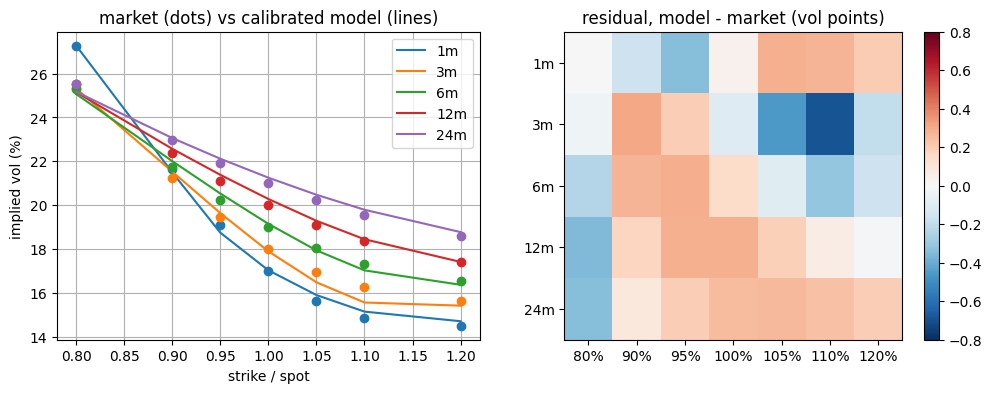

,80%,90%,95%,100%,105%,110%,120%
1m,-0.00,-0.17,-0.34,0.03,0.29,0.27,0.20
3m,-0.03,0.31,0.19,-0.10,-0.46,-0.69,-0.20
6m,-0.24,0.27,0.29,0.15,-0.10,-0.31,-0.16
12m,-0.35,0.17,0.28,0.28,0.19,0.06,-0.01
24m,-0.34,0.08,0.20,0.25,0.26,0.23,0.20


,market 90-110 skew,model 90-110 skew
1m,6.78,6.34
3m,4.96,5.96
6m,4.40,4.98
12m,4.01,4.12
24m,3.42,3.27


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, m in enumerate(MATS):
    ax[0].plot(STRIKES, 100 * MARKET[i], 'o', color=f'C{i}'); ax[0].plot(STRIKES, 100 * IV_FIT[m], '-', color=f'C{i}', label=f'{m}m')
ax[0].set_title('market (dots) vs calibrated model (lines)'); ax[0].set_xlabel('strike / spot'); ax[0].set_ylabel('implied vol (%)'); ax[0].legend()
im = ax[1].imshow(100 * resid, cmap='RdBu_r', vmin=-0.8, vmax=0.8, aspect='auto')
ax[1].set_xticks(range(len(STRIKES))); ax[1].set_xticklabels([f'{int(100*k)}%' for k in STRIKES]); ax[1].set_yticks(range(len(MATS))); ax[1].set_yticklabels([f'{m}m' for m in MATS])
ax[1].set_title('residual, model - market (vol points)'); plt.colorbar(im, ax=ax[1]); ax[1].grid(False); plt.show()
display(pd.DataFrame(100 * resid, index=[f'{m}m' for m in MATS], columns=[f'{int(100*k)}%' for k in STRIKES]).round(2))
pd.DataFrame({'market 90-110 skew': [skew_90_110(MARKET[i]) for i in range(len(MATS))],
              'model 90-110 skew': [skew_90_110(IV_FIT[m]) for m in MATS]}, index=[f'{m}m' for m in MATS]).round(2)


**Reading the residuals.** The fit is a quarter of a vol point RMSE over 35 quotes, the skew term
structure is reproduced from one month to two years, and the wing — where the put lives — is within
tolerance. The residual pattern that remains is *structural*, and worth recognising: at 3–6 months the
model's smile falls faster on the call side (105–110%) than this market's does. That is the two-shock
signature from 4.3: for the same skew, a model with an independent return shock carries more
convexity on the side away from the skew than a one-shock model, and this market wants a flatter
call wing than the mixture of jumps and leverage produces. It is a property of the model class, not of
the optimiser, and it is the kind of residual that should be in the model document rather than fitted
away with a leverage function (which would break requirement (d)).


### 5.3 Sizing diagnostics: is the fitted model a plausible model?

A vanilla fit is a necessary condition. These are the checks that catch a fit that is right for the
wrong reasons — each one is a number the model document should carry.


In [14]:
c_fit = 1 - P_FIT['rho_s'] ** 2 - P_FIT['rho_l'] ** 2
# cap headroom: fraction of path-days within 5 widths of the cap, on the fitted model over 3 years
g3 = Grid(n_blocks=36); Pn, Ln = unpack(x3, P, g3)
d3 = draws(g3, 2 ** 14, np.random.default_rng(9))
phi_l, phi_s, w_l, w_s = ou_coeffs(Pn, g3.dt); ell = np.full(2 ** 14, Ln[0]); s = np.zeros(2 ** 14); near = 0; maxv = -np.inf
for k in range(g3.n_steps):
    x = ell + s; near += np.mean((Pn['cap_a'] - x) / Pn['cap_beta'] < 5); maxv = max(maxv, x.max())
    N = poisson_counts(d3['uN'][:, k], Pn['lam'] * g3.dt)
    s = phi_s * s + w_s * d3['eta_s'][:, k] + Pn['nu'] * N; ell = Ln[k + 1] + phi_l * (ell - Ln[k]) + w_l * d3['eta_l'][:, k]
near /= g3.n_steps

diag = pd.DataFrame([
    ['jump share of total variance', P_FIT['lam'] * (P_FIT['mu_J']**2 + P_FIT['sigma_J']**2) / XI0, '0.15 - 0.30 (index SVJ estimates)'],
    ['fast leverage product rho_s*sigma_s', P_FIT['rho_s'] * P_FIT['sigma_s'], 'index skew needs about -1.2 to -2.5 across the two factors'],
    ['slow leverage product rho_l*sigma_l', P_FIT['rho_l'] * P_FIT['sigma_l'], ''],
    ['idiosyncratic share c', c_fit, '>= 0.12; OSS efficiency vs daily truncation ~ (sqrt(c)/0.22)^3'],
    ['OSS efficiency factor vs one-day truncation', (np.sqrt(c_fit) / 0.22) ** 3, 'second-order noise, monthly blocks'],
    ['stationary sd of log-vol', stationary_logvol_sd(P_FIT), '0.4 - 0.9 (VIX options at one year)'],
    ['fraction of path-days within 5 widths of the cap', near, '< 1e-5'],
    ['highest log-variance reached (vol %)', 100 * np.exp(0.5 * maxv), f'cap at {100*np.exp(0.5*Pn["cap_a"]):.0f}%'],
], columns=['diagnostic', 'value', 'reference']).set_index('diagnostic')
diag.round(4)


,value,reference
diagnostic,,
jump share of total variance,0.1494,0.15 - 0.30 (index SVJ estimates)
fast leverage product rho_s*sigma_s,-0.5027,index skew needs about -1.2 to -2.5 across the...
slow leverage product rho_l*sigma_l,-1.0113,
idiosyncratic share c,0.5874,>= 0.12; OSS efficiency vs daily truncation ~ ...
OSS efficiency factor vs one-day truncation,42.2794,"second-order noise, monthly blocks"
stationary sd of log-vol,0.9002,0.4 - 0.9 (VIX options at one year)
fraction of path-days within 5 widths of the cap,0.0000,< 1e-5
highest log-variance reached (vol %),568.8186,cap at 1000%


**Reading the diagnostics.** The jump share (15%) and the idiosyncratic share ($c \approx 0.6$, an OSS
efficiency factor of ~40 over one-day truncation) are comfortable. Two lines deserve a sentence in the
model document. The slow factor sits at its leverage bound ($\rho_\ell = -0.6$) with the stationary
spread at the top of its range (0.9): this surface wants more *persistent* skew than a plausible
distribution of future vol levels can carry, and the calibrator has taken all it was allowed. And the
highest vol reached on any path-day of a 3-year, 16,000-path run is ~570% — well below the cap and
consistent with a log-vol spread of 0.9, but a number a validator should see rather than infer.


### 5.4 Forward skew: what vanillas do not pin, and the lever that moves it

An autocall's coupon strip and its put are priced on the smile **conditional on having reached a
future date**. Vanillas say nothing about that. Two models with identical vanilla fits can differ by a
factor of two in forward skew; a calibrator that fits vanillas only *has not calibrated an autocall
model*.

The instrument is the **forward-start** option, $(S_{T_2}/S_{T_1} - k)^+$. Its payoff depends only on
the block return over $[T_1, T_2]$, whose law given the draws is lognormal, so it is priced by the same
conditional Black on the block statistics after walking the state to $T_1$ — no return is ever drawn.
We report the **stickiness ratio** $\psi$ = forward 90–110 skew divided by the spot 90–110 skew at the
same tenor.

Three facts about this model, all measured rather than argued:

1. **With constant parameters $\psi < 1$.** The forward-start return's variance includes the
   uncertainty of the vol state at $T_1$, generated *before* $T_1$ and carrying no leverage skew (the
   return before $T_1$ is not in the payoff). That extra variance dilutes leverage skew at the forward
   date. Jump skew is an absolute wing effect and is not diluted: jumps are the *sticky* part, and
   $\psi$ rises toward 1 with the jump share. It cannot pass 1. Reference models of the GARCH family
   sit at $\psi \approx 1.0$; the market, judged from forward-start quotes, sits close to 1 too.
2. **State-dependent parameters do not lever.** Making leverage, vol-of-vol or jump size depend on the
   vol level moves the spot smile (which already averages a year of states) and the forward smile
   *alike*; three such levers were tried and none moved $\psi$ to two decimals.
3. **Calendar time does.** The spot 1y smile never sees the parameters in force during year two; the
   1y-into-1y smile prices on nothing else. So $\rho_s(t)$ and $\mu_J(t)$ are piecewise constant on
   buckets aligned to the forward horizons. The 1y vanillas pin bucket one, the forward target pins
   bucket two, and the **2y vanillas become a composition check** — a residual to report, not absorb.

Below: $\psi$ for the vanilla-calibrated model, then the same with a steeper year-two bucket, and the
2y composition residual that buys it.


In [15]:
def forward_smile(W, grid, t1_block, dT_blocks, strikes):
    """Implied vols of forward-start options on S_{T2}/S_{T1}; the ratio's law given the draws is lognormal."""
    Mb = W['M'][:, t1_block:t1_block + dT_blocks].sum(1); S2b = W['S2'][:, t1_block:t1_block + dT_blocks].sum(1)
    F, sd = np.exp(Mb + 0.5 * S2b), np.sqrt(S2b); T = dT_blocks * grid.block_days / DAYS
    return np.array([implied_vol(black(F, k, sd).mean(), 1.0, k, T) for k in strikes])

grid = Grid(n_blocks=24); d_fwd = draws(grid, 2 ** 14, np.random.default_rng(12))
W0 = walk(grid, P_FIT, L_FIT, d_fwd)
spot_1y = model_smile(W0, 1.0, grid, [12], STRIKES)[12]; fwd_1y1y = forward_smile(W0, grid, 12, 12, STRIKES)
psi0 = skew_90_110(fwd_1y1y) / skew_90_110(spot_1y)

# a second calendar-time bucket: steeper fast leverage from year one onward
rho_t = bucket_on_grid(grid, np.array([0.0, 1.0]), [P_FIT['rho_s'], -0.60])
W1 = walk(grid, P_FIT, L_FIT, d_fwd, rho_s_t=rho_t)
sm1 = model_smile(W1, 1.0, grid, [12, 24], STRIKES); fwd1 = forward_smile(W1, grid, 12, 12, STRIKES)
psi1 = skew_90_110(fwd1) / skew_90_110(sm1[12])

sm0_2y = model_smile(W0, 1.0, grid, [24], STRIKES)[24]
pd.DataFrame({'spot 1y skew': [skew_90_110(spot_1y), skew_90_110(sm1[12])],
              '1y-into-1y skew': [skew_90_110(fwd_1y1y), skew_90_110(fwd1)],
              'stickiness psi': [psi0, psi1],
              '2y skew: model': [skew_90_110(sm0_2y), skew_90_110(sm1[24])],
              '2y skew: market': [skew_90_110(MARKET[4])] * 2,
              '2y residual RMSE (vol pts)': [100 * np.sqrt(np.nanmean((sm0_2y - MARKET[4])**2)), 100 * np.sqrt(np.nanmean((sm1[24] - MARKET[4])**2))]},
             index=['one bucket (vanillas only)', 'two buckets: rho_s = -0.60 from year one']).round(3)


,spot 1y skew,1y-into-1y skew,stickiness psi,2y skew: model,2y skew: market,2y residual RMSE (vol pts)
one bucket (vanillas only),4.229,3.617,0.855,3.205,3.418,0.208
two buckets: rho_s = -0.60 from year one,4.229,4.442,1.050,3.413,3.418,0.213


Two things to take from that table. The vanilla-calibrated model's forward skew is well below its spot
skew ($\psi \approx 0.85$) — the dilution mechanism at work, and larger here than at the default
parameters because this fit leans on the slow factor, whose state uncertainty at one year is large.
And the year-two bucket lifts $\psi$ above 1 at, in this case, **no cost** in the 2y vanillas: the
one-bucket fit had under-shot the 2y skew, and steeper year-two leverage repairs it while raising the
forward skew. That will not be true in general — a market whose 2y smile is exactly the composition
of its 1y smile and its 1y-into-1y forward smile under this model's conditional law is a coincidence —
and the 2y residual is the number that says whether the second bucket is free or paid for. It is the
same residual a local-stochastic-volatility model carries in its leverage function, made explicit.
Section 6 shows what the change is worth to the autocall.


## 6. Pricing the autocall

The pricer is the one from section 2, fed the calibrated model's block statistics on the deal's own
observation grid (36 monthly blocks). We price it four ways: OSS and brute force, each under the
one-bucket and the two-bucket calibration. The first pair is a correctness check (same value within
error, smaller error for OSS); the second pair is the **forward-skew sensitivity** of this deal — the
number that decides whether the second bucket matters.


In [16]:
grid = Grid(n_blocks=N_OBS); L_deal = np.interp(grid.t, KNOTS_T, x3[:len(KNOTS_T)])
d_deal = draws(grid, 2 ** 15, np.random.default_rng(21))
rho_t_deal = bucket_on_grid(grid, np.array([0.0, 1.0]), [P_FIT['rho_s'], -0.60])

rows, pvs = [], {}
for label, rst in [('one bucket (vanillas only)', None), ('two buckets (forward-skew target)', rho_t_deal)]:
    Wd = walk(grid, P_FIT, L_deal, d_deal, rho_s_t=rst, brute=True)
    pv_o = autocall_oss_from_stats(Wd['M'], Wd['S2'], d_deal['u_block'], 1.0, TRIGGER, BARRIER, COUPON)
    pv_b = autocall_brute_from_returns(Wd['Rb'], 1.0, TRIGGER, BARRIER, COUPON)
    pvs[label] = pv_o
    rows.append([label, 'OSS', pv_o.mean(), se(pv_o)]); rows.append([label, 'brute force', pv_b.mean(), se(pv_b)])
res_tab = pd.DataFrame(rows, columns=['calibration', 'estimator', 'value (of notional)', 'std error']).set_index(['calibration', 'estimator'])
paired = pvs['two buckets (forward-skew target)'] - pvs['one bucket (vanillas only)']      # same draws: the difference is precise
print(f"forward-skew sensitivity of this deal (two buckets minus one, paired on the same draws): {paired.mean():+.5f} +- {se(paired):.5f}"
      f"  = {100*paired.mean()/abs(pvs['one bucket (vanillas only)'].mean()):+.1f}% of the value")
res_tab.round(5)


forward-skew sensitivity of this deal (two buckets minus one, paired on the same draws): +0.00058 +- 0.00023  = +2.1% of the value


value (of notional)  std error
calibration                       estimator                                  
one bucket (vanillas only)        OSS                       0.0274     0.0006
                                  brute force               0.0282     0.0009
two buckets (forward-skew target) OSS                       0.0280     0.0006
                                  brute force               0.0289     0.0009

The value is small because the coupon strip and the put nearly offset at these levels — which is
exactly why its Greeks are what a desk trades, and why the estimator's smoothness matters more than
its mean. Below, the spot ladder again, now under the calibrated model, and a **vega** ladder obtained
by bumping the curve; both with common random numbers.

One feature of the product to expect in the ladder: with spot at the trigger, the delta is *small and
slightly negative*. A higher spot calls the note earlier, for a smaller accrued coupon, and that
outweighs the reduced put risk; the value peaks near the trigger and falls on both sides. A pricer
that returned a confidently positive delta here would be wrong, and the brute-force staircase makes
that sign impossible to read.


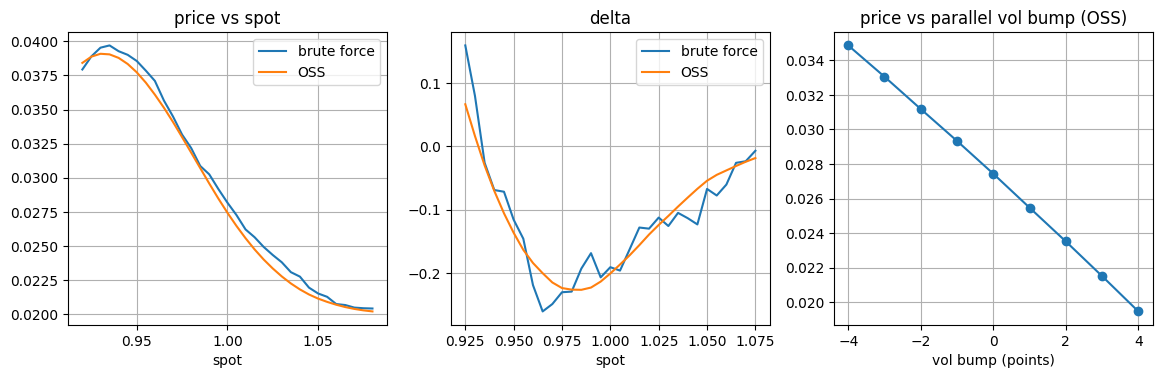

delta at spot (OSS, central difference):  -0.2010 per unit spot
vega (OSS):  -0.00193 per vol point   (negative: the holder is short the put's vol)


In [17]:
Wd = walk(grid, P_FIT, L_deal, d_deal, rho_s_t=None, brute=True)
spots = np.linspace(0.92, 1.08, 33)
oss_l = [autocall_oss_from_stats(Wd['M'], Wd['S2'], d_deal['u_block'], s, TRIGGER, BARRIER, COUPON).mean() for s in spots]
bru_l = [autocall_brute_from_returns(Wd['Rb'], s, TRIGGER, BARRIER, COUPON).mean() for s in spots]
bumps = np.linspace(-0.04, 0.04, 9)                      # parallel vol bump (in vol points of the curve): L -> log((sqrt(e^L)+bump)^2)
vega_l = []
for bmp in bumps:
    Lb = np.log((np.exp(0.5 * L_deal) + bmp) ** 2)
    Wb = walk(grid, P_FIT, Lb, d_deal)
    vega_l.append(autocall_oss_from_stats(Wb['M'], Wb['S2'], d_deal['u_block'], 1.0, TRIGGER, BARRIER, COUPON).mean())
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].plot(spots, bru_l, label='brute force'); ax[0].plot(spots, oss_l, label='OSS'); ax[0].set_title('price vs spot'); ax[0].legend(); ax[0].set_xlabel('spot')
ax[1].plot(spots[1:-1], np.gradient(bru_l, spots)[1:-1], label='brute force'); ax[1].plot(spots[1:-1], np.gradient(oss_l, spots)[1:-1], label='OSS'); ax[1].set_title('delta'); ax[1].legend(); ax[1].set_xlabel('spot')
ax[2].plot(100 * bumps, vega_l, 'o-'); ax[2].set_title('price vs parallel vol bump (OSS)'); ax[2].set_xlabel('vol bump (points)')
plt.show()
print(f"delta at spot (OSS, central difference):  {(oss_l[17]-oss_l[15])/(spots[17]-spots[15]):+.4f} per unit spot")
print(f"vega (OSS):  {(vega_l[5]-vega_l[3])/(2*0.01)*0.01:+.5f} per vol point   (negative: the holder is short the put's vol)")


## 7. The validation gates

Every claim above is a number here. These are the checks a model validator should be able to re-run
in isolation; the production versions live in the test suite with tighter tolerances and more paths.


In [18]:
gates = []
# G1 martingale, on the deal grid, from conditional moments
cM, cS2 = np.cumsum(Wd['M'], 1), np.cumsum(Wd['S2'], 1); F3 = np.exp(cM[:, -1] + 0.5 * cS2[:, -1])
gates.append(['G1  martingale E[S_3y] = 1', f'{F3.mean()-1:+.4f} +- {se(F3):.4f}', 'within 3 se'])
# G2 block Gaussian = iterated steps (from 4.5)
gates.append(['G2  block draw = summed step draws', f'KS = {ks.statistic:.4f}, p = {ks.pvalue:.2f}', 'p > 0.01'])
# G3 composability: one block vs its two halves, same draws -> identical statistics (exact identity)
g6 = Grid(block_days=42, n_blocks=18, n_sub=6); W6 = walk(g6, P_FIT, L_deal, d_deal)      # same 108 draws, 42-day blocks
gates.append(['G3  composability (2 x 21d blocks = 1 x 42d block)', f'max |dM| = {np.abs(W6["M"] - (Wd["M"][:, ::2] + Wd["M"][:, 1::2])).max():.1e}', '< 1e-12'])
# G4 OSS = brute force (from section 6, one bucket)
v = res_tab.loc[('one bucket (vanillas only)', 'OSS')]; b = res_tab.loc[('one bucket (vanillas only)', 'brute force')]
gates.append(['G4  OSS = brute force', f'diff {v.iloc[0]-b.iloc[0]:+.5f} vs se {np.hypot(v.iloc[1], b.iloc[1]):.5f}', 'within 3 se'])
# G5 ledger conservation: fired mass + surviving mass = 1 on every path
n = Wd['M'].shape[0]; logS = np.zeros(n); Lw = np.ones(n); fired_total = np.zeros(n)
for j in range(N_OBS):
    m, sd = Wd['M'][:, j], np.sqrt(Wd['S2'][:, j]); p = Phi((np.log(TRIGGER) - logS - m) / sd)
    fired_total += Lw * (1 - p); Lw *= p; logS += m + sd * Phinv(np.clip(d_deal['u_block'][:, j] * p, 1e-16, 1 - 1e-16))
gates.append(['G5  survival ledger conserved', f'max |fired + alive - 1| = {np.abs(fired_total + Lw - 1).max():.1e}', '< 1e-12'])
# G6 jump compensator
Nn = poisson_counts(np.random.default_rng(5).uniform(size=2_000_000), P_FIT['lam'] * 1.0); J = Nn * P_FIT['mu_J'] + P_FIT['sigma_J'] * np.sqrt(Nn) * np.random.default_rng(6).standard_normal(len(Nn))
comp = P_FIT['lam'] * (np.exp(P_FIT['mu_J'] + 0.5 * P_FIT['sigma_J'] ** 2) - 1)
gates.append(['G6  jump compensator E[exp(J - comp)] = 1 (T = 1y)', f'{np.mean(np.exp(J - comp)):.5f} +- {se(np.exp(J - comp)):.5f}', 'within 3 se'])
# G7 GBM limit: switch every non-GBM feature off -> matches Black-Scholes at the curve's vol
P_gbm = dict(P_FIT, sigma_s=1e-9, sigma_l=1e-9, rho_s=0.0, rho_l=0.0, lam=0.0, nu=0.0)
Wg = walk(Grid(n_blocks=12), P_gbm, np.full(Grid(n_blocks=12).n_steps + 1, np.log(0.04)), draws(Grid(n_blocks=12), 4096, np.random.default_rng(8)))
iv_g = model_smile(Wg, 1.0, Grid(n_blocks=12), [12], STRIKES)[12]
gates.append(['G7  GBM limit reproduces flat 20% vol', f'max |iv - 20%| = {100*np.nanmax(np.abs(iv_g - 0.2)):.2e} vol pts', '< 1e-6'])
# G8 no floor anywhere: audit the source of walk()
import inspect; src = inspect.getsource(walk)
gates.append(['G8  no clamp/floor on any variance quantity', 'none found' if 'clip' not in src and 'maximum' not in src else 'FOUND', 'none'])
pd.DataFrame(gates, columns=['gate', 'measured', 'pass mark']).set_index('gate')


,measured,pass mark
gate,,
G1 martingale E[S_3y] = 1,+0.0000 +- 0.0012,within 3 se
G2 block draw = summed step draws,"KS = 0.0060, p = 0.59",p > 0.01
G3 composability (2 x 21d blocks = 1 x 42d block),max |dM| = 8.9e-16,< 1e-12
G4 OSS = brute force,diff -0.00074 vs se 0.00104,within 3 se
G5 survival ledger conserved,max |fired + alive - 1| = 7.8e-16,< 1e-12
G6 jump compensator E[exp(J - comp)] = 1 (T = 1y),1.00001 +- 0.00004,within 3 se
G7 GBM limit reproduces flat 20% vol,max |iv - 20%| = 7.77e-14 vol pts,< 1e-6
G8 no clamp/floor on any variance quantity,none found,none


**G9 — convergence in the internal step.** The internal step $\delta$ is a numerical setting, not a
parameter: prices must converge as it shrinks, and calibration must run at the $\delta$ pricing uses.
The table prices the deal and reads the 1y smile at four step sizes with the *same* parameters.
Vanilla vols converge by the 7-day step (the monthly step is a few tenths of a vol point off). The
autocall converges more slowly: it is path-dependent, it reads the 70% wing, and the co-jump reaches
the variance one step *after* the return, so a coarser step delays the vol response by that step. The
7-day and 1-day values differ by a few percent of the value here, several standard errors. That is why
the rule is "calibrate and price at the same $\delta$" rather than "any $\delta$ will do", and why
production uses one day. This notebook uses 7 days for speed.


In [19]:
rows = []
for n_sub in [1, 3, 7, 21]:
    g = Grid(n_blocks=N_OBS, n_sub=n_sub); Lg = np.interp(g.t, KNOTS_T, x3[:len(KNOTS_T)])
    dg = draws(g, 2 ** 16, np.random.default_rng(5)); Wg = walk(g, P_FIT, Lg, dg)
    pv = autocall_oss_from_stats(Wg['M'], Wg['S2'], dg['u_block'], 1.0, TRIGGER, BARRIER, COUPON)
    iv = model_smile(Wg, 1.0, g, [12], STRIKES)[12]
    rows.append([f'{21//n_sub} days', pv.mean(), se(pv), 100 * iv[3], 100 * iv[1]])
pd.DataFrame(rows, columns=['internal step', 'autocall value', 'std error', '1y ATM vol (%)', '1y 90% vol (%)']).set_index('internal step').round(4)


,autocall value,std error,1y ATM vol (%),1y 90% vol (%)
internal step,,,,
21 days,0.0291,0.0004,20.2511,22.4159
7 days,0.0287,0.0004,20.3341,22.6393
3 days,0.0275,0.0004,20.4204,22.7847
1 days,0.0272,0.0004,20.5152,22.9098


## 8. What to remember

1. **Start from the estimator.** One-step survival needs the interval return to be Gaussian given
   everything sampled before it. That single requirement — not taste — decides the shape of the model:
   sample the non-Gaussian pieces first, put a Gaussian on top, never integrate inside a stride.
2. **Predictable variance, autonomous state.** The variance the return reads is fixed before the
   return's own shock is drawn; the state never sees the truncation; the carry is exact; there is no
   floor. This is also exactly why GARCH-type models cannot do it.
3. **Two shocks, one dial.** The independent return shock's share $c$ trades OSS efficiency ($c^{3/2}$)
   against skew per convexity ($\sqrt{1-c}$). The GARCH corner is $c\to0$. We floor $c$ and report it.
4. **Size under Q.** Leverage products and vol-of-vol come from VIX dynamics and VIX options, not from
   realised vol. Sizing to the wrong measure gave half the market's skew and looked like a modelling
   deficit.
5. **Jumps for the short end, structural $\lambda$.** Fewer, larger jumps; the intensity by a rule,
   so the count's non-differentiability never reaches a Greek.
6. **Vanillas do not close the model.** Forward skew is a separate target with a separate lever, and
   the lever is calendar time, not the state — measured, not argued. The 2y composition residual is
   the honest price of it.
7. **Every claim has a gate.** Martingale, block = iterated, composability as an identity, OSS = brute
   force, ledger conservation, the GBM limit, a no-floor audit, and convergence in $\delta$.

**Where this model is structurally short**, so nobody discovers it in production: it cannot reach the
skew-per-convexity of a one-shock model (the 105–110% residual in 5.2); constant parameters cannot put
$\psi$ above 1; its vol-of-vol under the cap has infinite moments of $S$ without it; and the jump
intensity is not a Greek.

*References for the pieces that are classical:* Glasserman & Staum (2001) for one-step survival;
Romano & Touzi (1997), Willard (1997) for conditioning on the volatility path; Bergomi (2016) for
two-factor lognormal variance and forward-skew thinking; Duffie, Pan & Singleton (2000) for co-jumps;
Gatheral & Jacquier (2014) for the SVI surface used as the stylised market.
